In [1]:
# Install necessary libraries (run once if required)

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize


In [7]:
# Load the dataset (financial news)
news_df = pd.read_csv('../data/raw_analyst_ratings.csv')

# Display the first few rows to inspect the data
news_df.head()


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [8]:
# Check for missing values in the dataset
news_df.isnull().sum()

# Check the data types of each column
news_df.dtypes


Unnamed: 0     int64
headline      object
url           object
publisher     object
date          object
stock         object
dtype: object

In [15]:
# Dropping the 'Unnamed: 0' column if it exists
news_df = news_df.drop(columns=['Unnamed: 0'], errors='ignore')

# Converting 'date' column to datetime format
news_df['date'] = pd.to_datetime(news_df['date'], errors='coerce', utc=True)

# Checking for any null values and data types after cleaning
print(news_df.isnull().sum())  # Checking for null values
print(news_df.dtypes)  # Checking the data types


headline           0
url                0
publisher          0
date         1351341
stock              0
dtype: int64
headline                  object
url                       object
publisher                 object
date         datetime64[ns, UTC]
stock                     object
dtype: object


In [16]:
# Dropping rows where 'date' is missing, as they are not useful for analysis
news_df = news_df.dropna(subset=['date'])

# Verifying the drop by checking the null values again
print(news_df.isnull().sum())

# Displaying the first few rows to verify
news_df.head()


headline     0
url          0
publisher    0
date         0
stock        0
dtype: int64


,headline,url,publisher,date,stock
0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 14:30:54+00:00,A
1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 14:45:20+00:00,A
2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 08:30:07+00:00,A
3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 16:45:06+00:00,A
4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 15:38:59+00:00,A


In [17]:
# Descriptive statistics for text length in headlines
news_df['headline_length'] = news_df['headline'].apply(len)

# Displaying basic statistics for the text lengths
headline_length_stats = news_df['headline_length'].describe()

# Display the statistics
headline_length_stats


count    55987.000000
mean        80.015254
std         56.126094
min         12.000000
25%         42.000000
50%         63.000000
75%         91.000000
max        512.000000
Name: headline_length, dtype: float64

In [19]:
# Count of articles by each publisher
publisher_activity = news_df['publisher'].value_counts()

# Display the top 10 publishers by article count
publisher_activity.head(10)


publisher
Benzinga Newsdesk    14750
Lisa Levin           12408
ETF Professor         4362
Paul Quintaro         4212
Benzinga Newsdesk     3177
Benzinga Insights     2332
Vick Meyer            2128
Charles Gross         1790
Hal Lindon            1470
Benzinga_Newsdesk     1239
Name: count, dtype: int64

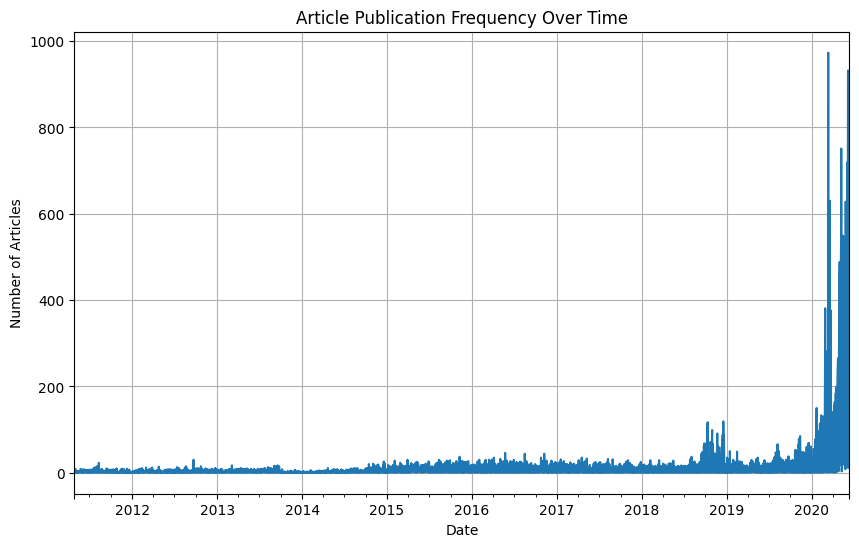

In [20]:
# Extracting date and converting it to a datetime format if needed (already done)
news_df['date'] = pd.to_datetime(news_df['date'])

# Resampling the data to count articles per day
articles_per_day = news_df.resample('D', on='date').size()

# Plotting the publication frequency over time
plt.figure(figsize=(10,6))
articles_per_day.plot()
plt.title('Article Publication Frequency Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Articles')
plt.grid(True)
plt.show()


In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# Vectorizing the headlines using TF-IDF
tfidf = TfidfVectorizer(stop_words='english', max_features=1000)
X = tfidf.fit_transform(news_df['headline'])

# Applying KMeans clustering for topic modeling
num_clusters = 5  # You can change this number based on your analysis
km = KMeans(n_clusters=num_clusters, random_state=42)
km.fit(X)

# Get the top terms per cluster
order_centroids = km.cluster_centers_.argsort()[:, ::-1]
terms = tfidf.get_feature_names_out()

# Print the top terms for each cluster
for i in range(num_clusters):
    print(f"Cluster {i + 1}:")
    print(" ".join([terms[ind] for ind in order_centroids[i, :10]]))  # top 10 terms per cluster
    print()


Cluster 1:
price etfs target eps biggest estimate movers maintains sales reports

Cluster 2:
moving session stocks pre day mid market wednesday tuesday monday

Cluster 3:
trading shares companies higher amid lower following economic optimism reopening

Cluster 4:
52 week hit stocks lows highs thursday friday set new

Cluster 5:
etf new benzinga reading bond mandatory 2013 dividend fee september



In [22]:
# Adding a new column 'sentiment' to store the sentiment polarity
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

# Apply sentiment analysis to the headlines
news_df['sentiment'] = news_df['headline'].apply(get_sentiment)

# Display the first few rows with sentiment values
news_df[['headline', 'sentiment']].head()

# Descriptive statistics for sentiment scores
news_df['sentiment'].describe()


count    55987.000000
mean         0.038009
std          0.155603
min         -1.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: sentiment, dtype: float64